### 2 预备知识
- GPU支持加速计算
- 张量类支持自动微分
#### 2.1 数据操作
##### 2.1.1 入门

In [4]:
import torch
x = torch.arange(12)
print(x)
print(x.shape)
print(x.numel())

X = x.reshape(3, 4)
print(X)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
torch.Size([12])
12
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


设置形状为（2，3，4）的张量
随机采样
嵌套列表

In [16]:
print(torch.zeros((2,3,4)))
print(torch.randn(3, 4))
print(torch.tensor([[2, 1, 4, 3],
                    [1, 2, 3, 4],
                    [4, 3, 2, 1]]))

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])
tensor([[ 0.8211, -0.6316, -1.2294, -0.3219],
        [ 0.2728, -1.3031, -1.0873, -0.2503],
        [ 0.0710, -0.3787, -0.3379, -2.7369]])
tensor([[2, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])


##### 2.1.2 运算符

按元素计算，通过将标量函数升级为按元素向量运算来生成向量值
$F:\mathbb{R}^d, \mathbb{R}^d \to \mathbb{R}$

In [19]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x ** y

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

多个张量连接：

In [21]:
X = torch.arange(12, dtype=torch.float32).reshape((3, 4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1), torch.cat((X, Y), dim=0), X == Y

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[False,  True, False,  True],
         [False, False, False, False],
         [False, False, False, False]]))

##### 2.1.3 广播机制
- 广播机制（Broadcasting Mechanism）：形状不同情况下的按元素操作。
- - 通过适当复制元素来扩展一个或两个数组，使转换后具有相同形状。
- - 对生成的数组进行按元素操作。

In [23]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b, a + b
# a复制列，b复制行

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]),
 tensor([[0, 1],
         [1, 2],
         [2, 3]]))

##### 2.1.4 索引和切片

In [29]:
print(X[-1], X[1:3])
X[1, 2] = 999
print(X)
X[0:2, :] = 12
print(X)

tensor([ 8.,  9., 10., 11.]) tensor([[12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])
tensor([[ 12.,  12.,  12.,  12.],
        [ 12.,  12., 999.,  12.],
        [  8.,   9.,  10.,  11.]])
tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])


##### 2.1.5 节省内存
执行原地操作：使用切片表示法将操作的结果分配给先前分配的数组。

对于可变对象，使用```Y = Y + X```，会开辟新的内存空间，而使用```Y += X```或```Y[:] = Y + X```是在原有内存空间上修改等价。

对于不可变对象（如int/tuple），```Y += X```和```Y = Y + X```等价。

In [33]:
Z = torch.zeros_like(Y)
print('id(Z):', id(Z))
Z[:] = X + Y
print('id(Z):', id(Z))

before_y = id(Y)
Y = Y + X
compare_y = id(Y) == before_y
print(compare_y)

before_x = id(X)
X += Y
compare_x = id(X) == before_x
print(compare_x)

id(Z): 2712959745680
id(Z): 2712959745680
False
True


##### 2.1.6 转换为其他Python对象
torch张量和numpy数组共享底层内存，就地操作更改一个张量也会同时更改另一个张量

In [36]:
A = X.numpy()
B = torch.tensor(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

将大小为1的张量转换为Python标量，调用item函数或Python内置函数

In [37]:
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

#### 2.2 数据预处理
##### 2.2.1 读取数据集

In [39]:
import os
import pandas as pd
os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms, Alley, Price\n')
    f.write('NA, Pave, 127500\n')
    f.write('2, NA, 106000\n')
    f.write('4, NA, 178100\n')
    f.write('NA, NA, 140000\n')

data = pd.read_csv(data_file)
print(data)

   NumRooms  Alley   Price
0       NaN   Pave  127500
1       2.0     NA  106000
2       4.0     NA  178100
3       NaN     NA  140000


##### 2.2.2 处理缺失值
典型方法为插值法、删除法，此处选择插值法替代缺失值。

##### 2.2.3 转换为张量格式

#### 2.3 线性代数
##### 2.3.1 标量

In [41]:
x = torch.tensor(3.0)
y = torch.tensor(2.0)
x + y, x - y, x * y, x / y, x ** y

(tensor(5.), tensor(1.), tensor(6.), tensor(1.5000), tensor(9.))

##### 2.3.2 向量

In [44]:
x = torch.arange(4)
x, x[3], len(x), x.shape

(tensor([0, 1, 2, 3]), tensor(3), 4, torch.Size([4]))

##### 2.3.3 矩阵

In [57]:
A = torch.arange(20).reshape(5, 4)
print(A, A.T)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]]) tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])


##### 2.3.4 张量
向量是一阶张量，矩阵是二阶张量，使用大写字母表示。

索引：$x_{ijk}, [X]_{1,2i-1,3}$

In [59]:
X = torch.arange(24).reshape(2, 3, 4)
print(X)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])


##### 2.3.5 张量算法的基本性质
##### 2.3.6 降维

In [65]:
x = torch.arange(4, dtype=torch.float32)
x, x.sum(), x.mean(), x.max(), x.numel()

(tensor([0., 1., 2., 3.]), tensor(6.), tensor(1.5000), tensor(3.), 4)

##### 2.3.7 点积
$x^Ty=\sum^d _{i=1}x_iy_i$

In [68]:
y = torch.ones(4, dtype=torch.float32)
x, y, torch.dot(x, y), torch.sum(x * y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.), tensor(6.))

##### 2.3.8 矩阵-向量积

In [79]:
x, x


(tensor([0., 1., 2., 3.]), tensor([0., 1., 2., 3.]))

#### 2.4 微积分
**微分——优化问题**

- 优化（Optimization）：用模型拟合观察数据的过程。
- 泛化（Generalization）：数学原理和实践者的智慧，指导生成有效性超出用于训练的数据集本身的模型。

$f:\mathbb{R} \to \mathbb{R}$

$f'(x)=\lim _{h \to 0}\frac{f(x+h)-f(x)}{h}$

#### 2.5 自动微分
- 自动微分（Automatic Differentiation）：深度学习框架通过自动计算导数。
- 计算图（Computational Graph）：跟踪计算是哪些数据通过哪些操作组合起来产生输出，使系统能够随后反向传播梯度。
- 反向传播（Backpropagate）：跟踪整个计算图填充关于每个参数的偏导数

##### 2.5.1 举例
对$y=2\textbf{x}^T\textbf{x}$关于列向量$\textbf{x}$求导。

```python
x = torch.arange(4.0, requires_grad=True)
```
分配一个区域存储梯度x.grad。

In [5]:
x = torch.arange(4.0, requires_grad=True) # 分配一个区域存储梯度x.grad
y = 2 * torch.dot(x,x)
y.backward() # 调用反向传播
x, x.grad, y

(tensor([0., 1., 2., 3.], requires_grad=True),
 tensor([ 0.,  4.,  8., 12.]),
 tensor(28., grad_fn=<MulBackward0>))

##### 2.5.2 非标量变量的反向传播
求导结果可以是矩阵、高阶张量。
##### 2.5.3 分离计算
计算$z=f(x,y)$梯度时，希望将$y$视作常数，只考虑$x$在$y$被计算后发挥的作用。

In [7]:
x.grad.zero_()  # 梯度会累积，此处要清空
y = x * x
u = y.detach()
z = u * x
z.sum().backward()
x.grad

tensor([0., 1., 4., 9.])

##### 2.5.4 Python控制流的梯度计算
while迭代次数和if语句结果取决于输入a的值。

In [9]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
        if b.sum() > 0:
            c = b
        else:
            c = 100 * b
        return c

a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()
a.grad, a.grad == d / a

(tensor(4.), tensor(True))

#### 2.6 概率
##### 2.6.1 基本概率论
**大数定律**
- 抽样（Sample）：在索引i处的值时采样结果中i出现的次数
```python
multinomial.Multinomial(10, fair_probs).sample()
```
进行10次抽样，避免for循环

In [7]:
from torch.distributions import multinomial
fair_probs = torch.ones([6]) / 6

counts = multinomial.Multinomial(1000, fari_probs).sample()
counts / 1000

tensor([0.1900, 0.1580, 0.1730, 0.1710, 0.1490, 0.1590])

进行500组实验，每组抽取10个样本。

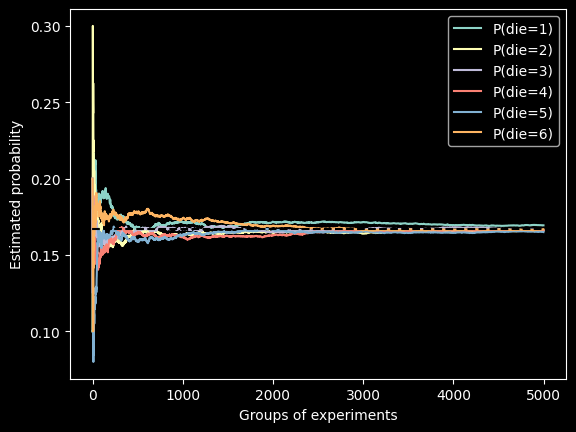

In [8]:
from matplotlib import pyplot as plt

counts = multinomial.Multinomial(10, fair_probs).sample((5000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=("P(die=" + str(i + 1) + ")"))
plt.axhline(y=0.167, color='black', linestyle='dashed')
plt.gca().set_xlabel('Groups of experiments')
plt.gca().set_ylabel('Estimated probability')
plt.legend();